# SA Implementation v4 — Room Types, Weighted Preferences, Dual Objectives

Builds directly on `SA_Implementation_v2.ipynb` (same structure, same constraint IDs,
same comment style), extended per the Aug 2 supervisor meeting. Nothing from v2 was
rewritten from scratch, everything below either reuses v2's logic unchanged (H2-H6,
L1-L2, the diagnostics/plotting pattern) or extends it in place.

**What's new in this version:**

| | v2 | v3 (this notebook) |
|---|---|---|
| Room selection | random room, any type | respects capacity **and** room type (Lab/General), matched to the session's current room type |
| Merged groups | could be split apart by an uncoordinated move | move **atomically** — every member of a group relocates together |
| Campus field | stale after a room move (a real bug) | recomputed from the new room every time a session moves |
| Tutor preferences | 6 profiles, one per tutor | **8 profiles, weighted vectors summing to 1 per tutor** (see Section 5) |
| Fairness | Jain's index (primary) + math view (secondary) | **two full objective-function versions**, one Jain-primary, one math-primary, each with the other reported only; **Gini and Atkinson** added as further reported metrics |
| Experiment design | one SA run | **three-stage**: baseline -> aggregate-only SA (no fairness term) -> fairness SA, both objective versions |
| Robustness | single seed | **10+ seeds**, logged and compared in a table |

Room types, the 8-profile generator, and everything data-related lives in
`Clean_Data_V3.ipynb` — this notebook consumes that output, it doesn't redo cleaning.


## 0. Configuration

In [1]:
import csv
import math
import random
import time
from collections import defaultdict, Counter
import pandas as pd
import matplotlib.pyplot as plt

# ---- single semester per run ----
SEMESTER = "25B"
DATA_DIR = "."   # folder containing the Cleaned Data V4 files -- adjust to your local path

SCHEDULE_CSV = f"{DATA_DIR}/schedule_cleaned_it_{SEMESTER}.csv"
TUTOR_PROFILE_CSV = f"{DATA_DIR}/tutors_anonymized_it.csv"
ROOM_CSV = f"{DATA_DIR}/rooms_capacities.csv"
COURSE_CLASH_TEMPLATE = f"{DATA_DIR}/Course_Clash_Avoidance_Template.xlsx"

# ---- objective weights (unchanged from v2 / the objective-function doc) ----
HARD_PENALTY = 1000     # alpha
LOGICAL_PENALTY = 50    # beta
IDLE_CAP_MINUTES = 240  # L1: 4-hour idle cap
SLOT_MINUTES = 120
ATKINSON_EPSILON = 0.5  # reported Atkinson uses this; not optimised against either way

PROFILE_COLS = [f"P{i}" for i in range(1, 9)]
TOTAL_DAYS_AVAILABLE = 5  # Sunday-Thursday, Friday/Saturday excluded at cleaning

# ---- simulated annealing hyperparameters ----
# Reduced from v2's 20000 to keep this notebook's total runtime (2 objectives x 3 stages
# x 10-seed robustness table) reasonable in one sitting. Starting points, not tuned --
# same caveat as v2, scale up yourself once you're past the correctness-checking stage.
MAIN_RUN_ITERATIONS = 10000
ROBUSTNESS_ITERATIONS = 3000
ROBUSTNESS_SEED_COUNT = 10
T0 = 50.0
COOLING = 0.998


## 1. Load data

Same duration/slot-unit model as v2 (`slots_needed = ceil(duration/120)`, real duration
kept, scheduling happens in whole 2-hour blocks). New here: each session's **room
type** (Lab/General) is looked up from `rooms_capacities.csv`, and each tutor's **weight
vector** across all 8 profiles is loaded instead of a single profile ID.

In [2]:
def load_csv(path):
    with open(path, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))

schedule_rows = load_csv(SCHEDULE_CSV)
room_rows = load_csv(ROOM_CSV)
tutor_rows = load_csv(TUTOR_PROFILE_CSV)

room_capacity_by_id = {r["ROOM_ID"]: int(r["CAPACITY"]) for r in room_rows}
room_type_by_id = {r["ROOM_ID"]: r["ROOM_TYPE"] for r in room_rows}
room_building_by_id = {r["ROOM_ID"]: r["BUILDING_ID"] for r in room_rows}

def derive_campus(building_id):
    """Same rule as the cleaning notebook: trailing letter is the campus; no letter -> A;
    UOB -> B by confirmed fallback."""
    if building_id == "UOB":
        return "B"
    last = building_id[-1]
    return last if last.isalpha() else "A"

room_campus_by_id = {rid: derive_campus(b) for rid, b in room_building_by_id.items()}

tutor_weights = {r["TUTOR_ID"]: {p: float(r[p]) for p in PROFILE_COLS} for r in tutor_rows}

def to_minutes(hhmm):
    h, m = map(int, hhmm.split(":"))
    return h * 60 + m

DAY_ORDER = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

def slots_needed_for(duration_minutes):
    return math.ceil(duration_minutes / SLOT_MINUTES)

sessions = []
for r in schedule_rows:
    start_min = to_minutes(r["START_TIME"])
    end_min = to_minutes(r["END_TIME"])
    sessions.append({
        "course": r["COURSE_ID"], "class_id": r["CLASS_ID"], "section": r["SECTION"],
        "tutor": r["TUTOR_ID"], "enrolled": int(r["ENROLLED_STUDENTS"]),
        "day": r["DAY"], "start": start_min, "duration": end_min - start_min,
        "slots_needed": slots_needed_for(end_min - start_min),
        "room": r["ROOM_ID"], "campus": r["CAMPUS_ID"],
        "merged_group": r["MERGED_GROUP_ID"] or None,
    })

def session_end(s):
    return s["start"] + s["slots_needed"] * SLOT_MINUTES

# ---- available slots: this semester's own real occupied times, unchanged from v2 ----
slot_starts_by_day = defaultdict(set)
for s in sessions:
    slot_starts_by_day[s["day"]].add(s["start"])

def valid_starts_for(day, slots_needed):
    starts = slot_starts_by_day.get(day, set())
    return [st for st in starts if all((st + i * SLOT_MINUTES) in starts for i in range(slots_needed))]

all_room_ids = sorted(room_capacity_by_id.keys())
rooms_by_type = defaultdict(list)
for rid, rtype in room_type_by_id.items():
    rooms_by_type[rtype].append(rid)

print(f"Semester {SEMESTER}: {len(sessions)} sessions, "
      f"{len(set(s['tutor'] for s in sessions))} tutors, "
      f"{sum(1 for s in sessions if s['merged_group'])} sessions in a merged group.")
print(f"Rooms by type: {dict((k, len(v)) for k, v in rooms_by_type.items())}")
print(f"Multi-slot sessions (slots_needed > 1): {sum(1 for s in sessions if s['slots_needed'] > 1)}")

pd.DataFrame(sessions).head()


Semester 25B: 556 sessions, 79 tutors, 30 sessions in a merged group.
Rooms by type: {'Lab': 51, 'General': 11}
Multi-slot sessions (slots_needed > 1): 0


,course,class_id,section,tutor,enrolled,day,start,duration,slots_needed,room,campus,merged_group
0,IT6001,20873,001,T118,24,Monday,720,110,1,5.04,A,NaN
1,IT6001,20873,001,T118,24,Wednesday,720,110,1,5.04,A,NaN
2,IT6001,20878,003,T118,24,Tuesday,600,110,1,5.05,A,NaN
3,IT6001,20878,003,T118,24,Sunday,600,110,1,5.05,A,NaN
4,IT6001,20881,004,T118,26,Monday,600,110,1,5.05,A,NaN


## 2. Hard constraints (H1-H6)

Unchanged from v2: same functions, same logic, reused as-is. `H1` is still structural
(guaranteed by the data representation). Merged-group exclusion in H2/H3, combined
capacity check in H4, campus-based H5, and the two-part H6 all carry over exactly.

In [3]:
def h2_h3_clashes(sessions_state):
    """Room (H2) and tutor (H3) clashes via interval overlap. Sessions sharing a
    MERGED_GROUP_ID are one physical session, excluded from clashing with each other."""
    room_groups = defaultdict(list)
    tutor_groups = defaultdict(list)
    for s in sessions_state:
        room_groups[(s["room"], s["day"])].append(s)
        tutor_groups[(s["tutor"], s["day"])].append(s)

    def count_overlaps(groups):
        total = 0
        for key, items in groups.items():
            items = sorted(items, key=lambda s: s["start"])
            for i in range(len(items)):
                for j in range(i + 1, len(items)):
                    if items[j]["start"] >= session_end(items[i]):
                        break
                    gi, gj = items[i]["merged_group"], items[j]["merged_group"]
                    if gi is not None and gi == gj:
                        continue
                    total += 1
        return total
    return count_overlaps(room_groups), count_overlaps(tutor_groups)


def h4_capacity_violations(sessions_state):
    """Merged-group enrollments are summed and checked together against the room's
    capacity, not row-by-row."""
    merged_totals = defaultdict(int)
    merged_room = {}
    for s in sessions_state:
        if s["merged_group"]:
            merged_totals[s["merged_group"]] += s["enrolled"]
            merged_room[s["merged_group"]] = s["room"]

    violations, unknown_skipped = 0, 0
    checked_groups = set()
    for s in sessions_state:
        if s["merged_group"]:
            if s["merged_group"] in checked_groups:
                continue
            checked_groups.add(s["merged_group"])
            cap = room_capacity_by_id.get(merged_room[s["merged_group"]])
            if cap is None:
                unknown_skipped += 1; continue
            if cap < merged_totals[s["merged_group"]]:
                violations += 1
        else:
            cap = room_capacity_by_id.get(s["room"])
            if cap is None:
                unknown_skipped += 1; continue
            if cap < s["enrolled"]:
                violations += 1
    return violations, unknown_skipped


def h5_cross_campus(sessions_state):
    """Consecutive (zero-gap) same-day sessions for a tutor in different CAMPUS_ID.
    Relies on session["campus"] being current -- see the SA loop's campus fix below,
    this is exactly the field that bug used to leave stale after a room move."""
    tutor_day = defaultdict(list)
    for s in sessions_state:
        tutor_day[(s["tutor"], s["day"])].append(s)
    total = 0
    for key, items in tutor_day.items():
        items = sorted(items, key=lambda s: s["start"])
        for i in range(len(items) - 1):
            if items[i+1]["start"] == session_end(items[i]) and items[i]["campus"] != items[i+1]["campus"]:
                total += 1
    return total


def h6a_two_section_courses(sessions_state):
    """Automatic: any course with exactly 2 sections has those sections kept from
    overlapping each other. Applies to ALL courses meeting this criterion, unconditional
    on year/major (confirmed) -- separate from the manually curated H6b groups below."""
    by_course_section = defaultdict(list)
    for s in sessions_state:
        by_course_section[(s["course"], s["section"])].append(s)
    course_sections = defaultdict(set)
    for course, section in by_course_section:
        course_sections[course].add(section)

    total = 0
    for course, secs in course_sections.items():
        if len(secs) != 2:
            continue
        secs = sorted(secs)
        group_a, group_b = by_course_section[(course, secs[0])], by_course_section[(course, secs[1])]
        for sa in group_a:
            for sb in group_b:
                if sa["day"] == sb["day"] and sb["start"] < session_end(sa) and sa["start"] < session_end(sb):
                    total += 1
    return total


def load_course_clash_groups(path, semester):
    try:
        df = pd.read_excel(path, sheet_name="Course_Clash_Groups")
    except FileNotFoundError:
        print(f"WARNING: {path} not found -- H6b will contribute 0.")
        return []
    groups = []
    for _, row in df.iterrows():
        if str(row.get("COHORT_LABEL", "")).strip().upper().startswith("EXAMPLE"):
            continue
        if str(row.get("SEMESTER", "")).strip() != semester:
            continue
        courses = [str(row[c]).strip() for c in ["COURSE_1", "COURSE_2", "COURSE_3", "COURSE_4"]
                   if str(row.get(c, "")).strip() and str(row[c]).strip().lower() != "nan"]
        if len(courses) >= 2:
            groups.append(courses)
    return groups


def h6b_manual_course_groups(sessions_state, course_groups):
    by_course = defaultdict(list)
    for s in sessions_state:
        by_course[s["course"]].append(s)
    total = 0
    for group in course_groups:
        for i in range(len(group)):
            for j in range(i + 1, len(group)):
                for sa in by_course.get(group[i], []):
                    for sb in by_course.get(group[j], []):
                        if sa["day"] == sb["day"] and sb["start"] < session_end(sa) and sa["start"] < session_end(sb):
                            total += 1
    return total

course_clash_groups = load_course_clash_groups(COURSE_CLASH_TEMPLATE, SEMESTER)
print(f"Manual course-clash groups loaded for {SEMESTER}: {len(course_clash_groups)}")


def count_hard_violations_breakdown(sessions_state):
    room_c, tutor_c = h2_h3_clashes(sessions_state)
    cap_v, cap_unknown = h4_capacity_violations(sessions_state)
    return {
        "H1_assignment_completeness": 0,
        "H2_room_clash": room_c, "H3_tutor_clash": tutor_c,
        "H4_capacity": cap_v, "H4_capacity_unknown_skipped": cap_unknown,
        "H5_cross_campus": h5_cross_campus(sessions_state),
        "H6a_two_section_overlap": h6a_two_section_courses(sessions_state),
        "H6b_manual_group_overlap": h6b_manual_course_groups(sessions_state, course_clash_groups),
    }

def count_hard_violations(sessions_state):
    b = count_hard_violations_breakdown(sessions_state)
    return sum(v for k, v in b.items() if k != "H4_capacity_unknown_skipped")


Manual course-clash groups loaded for 25B: 0


## 3. Logical constraints (L1, L2)

Unchanged from v2. `L2` is the renamed `H7` (same class, same day).

In [4]:
def l1_idle_cap_violations(sessions_state):
    tutor_day = defaultdict(list)
    for s in sessions_state:
        tutor_day[(s["tutor"], s["day"])].append(s)
    total = 0
    for key, items in tutor_day.items():
        items = sorted(items, key=lambda s: s["start"])
        for i in range(len(items) - 1):
            if items[i+1]["start"] - session_end(items[i]) > IDLE_CAP_MINUTES:
                total += 1
    return total


def l2_same_class_same_day(sessions_state):
    groups = defaultdict(list)
    for s in sessions_state:
        groups[s["class_id"]].append(s["day"])
    total = 0
    for class_id, days in groups.items():
        day_counts = Counter(days)
        total += sum(c - 1 for c in day_counts.values() if c > 1)
    return total

def count_logical_violations_breakdown(sessions_state):
    return {"L1_idle_gap_over_4h": l1_idle_cap_violations(sessions_state),
            "L2_same_class_same_day": l2_same_class_same_day(sessions_state)}

def count_logical_violations(sessions_state):
    return sum(count_logical_violations_breakdown(sessions_state).values())


## 4. Soft constraints — 8-profile weighted penalty

Replaces v2's single-profile lookup. Each tutor has a **weight per profile**, summing to
1 (built in the cleaning notebook); the penalty for each active profile is computed and
combined via the tutor's own weights, `V_t = Σ_p weight_p × Penalty_p(s)`.

| ID | Meaning | Penalty |
|---|---|---|
| P1 | Morning-only | +1 per session at/after 12:00 |
| P2 | Night owl | +1 per session before 12:00 |
| P3 | Compact week | number of distinct days used |
| P4 | Prefers full week (new) | `TOTAL_DAYS_AVAILABLE - distinct days used` — the direct opposite of P3 |
| P5 | Prefers idle time | count of back-to-back (zero-gap) pairs |
| P6 | Dislikes idle time | count of idle gaps |
| P7 | Campus-consistency (new) | Σ over days with more than one campus visited, of `(distinct campuses that day - 1)` |
| P8 | No preference | 0, always |

In [5]:
def is_morning(start_minute):
    return start_minute < 12 * 60

def profile_penalty(profile, day_groups, campus_by_day):
    if profile == "P1":
        return sum(1 for day, items in day_groups.items() for s in items if not is_morning(s["start"]))
    if profile == "P2":
        return sum(1 for day, items in day_groups.items() for s in items if is_morning(s["start"]))
    if profile == "P3":
        return len(day_groups)
    if profile == "P4":
        return max(TOTAL_DAYS_AVAILABLE - len(day_groups), 0)
    if profile == "P5":
        total = 0
        for day, items in day_groups.items():
            its = sorted(items, key=lambda s: s["start"])
            for i in range(len(its) - 1):
                if its[i+1]["start"] == session_end(its[i]):
                    total += 1
        return total
    if profile == "P6":
        total = 0
        for day, items in day_groups.items():
            its = sorted(items, key=lambda s: s["start"])
            for i in range(len(its) - 1):
                if its[i+1]["start"] > session_end(its[i]):
                    total += 1
        return total
    if profile == "P7":
        total = 0
        for day, campuses in campus_by_day.items():
            distinct = len(set(campuses))
            if distinct > 1:
                total += distinct - 1
        return total
    return 0.0  # P8


def per_tutor_violations(sessions_state):
    """Returns (V_raw, V_norm). V_raw is the tutor's own weighted sum across all 8
    profiles; V_norm additionally divides by their number of distinct classes (per-class
    normalization, unchanged from v2, confirmed to also apply to this weighted sum)."""
    tutor_days = defaultdict(lambda: defaultdict(list))
    tutor_campus_days = defaultdict(lambda: defaultdict(list))
    tutor_classes = defaultdict(set)
    for s in sessions_state:
        tutor_days[s["tutor"]][s["day"]].append(s)
        tutor_campus_days[s["tutor"]][s["day"]].append(s["campus"])
        tutor_classes[s["tutor"]].add(s["class_id"])

    V_raw, V_norm = {}, {}
    for t, day_groups in tutor_days.items():
        weights = tutor_weights.get(t, {p: (1.0 if p == "P8" else 0.0) for p in PROFILE_COLS})
        weighted_sum = 0.0
        for p in PROFILE_COLS:
            w = weights.get(p, 0.0)
            if w == 0.0:
                continue
            weighted_sum += w * profile_penalty(p, day_groups, tutor_campus_days[t])
        n_classes = max(len(tutor_classes[t]), 1)
        V_raw[t] = weighted_sum
        V_norm[t] = weighted_sum / n_classes
    return V_raw, V_norm


## 5. Fairness — four independent views

Jain's index and the mean/SD/max view carry over from v2. **Gini** and **Atkinson** are
new, added per your instruction, both computed independently from `V_norm`, never
derived from Jain's or from each other. All four are always reported; which one (if any)
actually drives the search is decided per-objective in Section 6.

In [6]:
def jain_fairness(V_dict):
    vals = list(V_dict.values())
    T = len(vals)
    if T == 0: return 1.0
    v_max = max(vals)
    shifted = [v_max - v for v in vals]
    s1, s2 = sum(shifted), sum(v * v for v in shifted)
    if s2 == 0: return 1.0
    return (s1 ** 2) / (T * s2)


def gini_fairness(V_dict):
    """Fairness = 1 - Gini. G = sum_i sum_j |xi-xj| / (2 n^2 xbar). Jain, Gini & Atkinson
    formulas per Munoz-Valero et al. 2025 (arxiv.org/abs/2504.17489), a fairness-oriented
    railway timetabling paper using exactly these three metrics together."""
    vals = list(V_dict.values())
    n = len(vals)
    if n == 0 or sum(vals) == 0: return 1.0
    xbar = sum(vals) / n
    total_abs_diff = sum(abs(a - b) for a in vals for b in vals)
    G = total_abs_diff / (2 * n * n * xbar)
    return 1 - G


def atkinson_fairness(V_dict, epsilon):
    """Fairness = 1 - A(epsilon). Values shifted by +1 since Atkinson requires strictly
    positive inputs and a violation count of 0 is common and valid here."""
    vals = [v + 1.0 for v in V_dict.values()]
    n = len(vals)
    if n == 0: return 1.0
    mu = sum(vals) / n
    if mu == 0: return 1.0
    if epsilon == 1:
        prod = 1.0
        for v in vals: prod *= v
        ede = prod ** (1.0 / n)
    else:
        ede = (sum(v ** (1 - epsilon) for v in vals) / n) ** (1.0 / (1 - epsilon))
    return 1 - (1 - ede / mu)


def mathematical_fairness(V_dict):
    vals = list(V_dict.values())
    n = len(vals)
    if n == 0: return {"mean": 0.0, "sd": 0.0, "max": 0.0}
    mean = sum(vals) / n
    variance = sum((v - mean) ** 2 for v in vals) / n
    return {"mean": mean, "sd": math.sqrt(variance), "max": max(vals)}


## 6. Two objective functions

Per your instruction: two complete, self-contained versions, so cells for whichever one
your research doesn't end up using can just be deleted later without touching the other.

- **Objective A (`cost_jain_primary`)**: Jain's index drives the search. Gini, Atkinson,
  and the math view are computed and reported, but do not affect the returned cost.
- **Objective B (`cost_math_primary`)**: the math view drives the search — specifically
  **standard deviation** of `V_norm`, the direct spread/inequality analogue of `1-J`
  (SD = 0 means every tutor has an identical normalized violation score, i.e. perfectly
  equal). This is a documented design choice, not the only valid one, mean or max could
  substitute here just as easily, change it in one place if you want a different driver.
  Jain's, Gini, and Atkinson are computed and reported, not part of the returned cost.
- **`cost_aggregate_only`**: no fairness term at all, for the baseline-vs-fairness
  comparison in Section 8.

All three report both the raw, unbounded cost and a normalized version, per your
instruction to keep both.

In [7]:
def _normalize(total, n_sessions):
    N = max(n_sessions, 1)
    ceiling = HARD_PENALTY * N + LOGICAL_PENALTY * N + 1
    return total / ceiling


def cost_jain_primary(sessions_state):
    hard = count_hard_violations(sessions_state)
    logical = count_logical_violations(sessions_state)
    V_raw, V_norm = per_tutor_violations(sessions_state)
    J = jain_fairness(V_norm)
    F_active = 1 - J
    total = HARD_PENALTY * hard + LOGICAL_PENALTY * logical + F_active
    return {
        "total": total, "normalized_total": _normalize(total, len(sessions_state)),
        "hard": hard, "logical": logical, "V_raw": V_raw, "V_norm": V_norm,
        "F_active": F_active, "jain": J, "gini": gini_fairness(V_norm),
        "atkinson": atkinson_fairness(V_norm, ATKINSON_EPSILON), "math": mathematical_fairness(V_norm),
    }


def cost_math_primary(sessions_state):
    hard = count_hard_violations(sessions_state)
    logical = count_logical_violations(sessions_state)
    V_raw, V_norm = per_tutor_violations(sessions_state)
    math_view = mathematical_fairness(V_norm)
    F_active = math_view["sd"]  # driving term for this version -- see markdown above
    total = HARD_PENALTY * hard + LOGICAL_PENALTY * logical + F_active
    return {
        "total": total, "normalized_total": _normalize(total, len(sessions_state)),
        "hard": hard, "logical": logical, "V_raw": V_raw, "V_norm": V_norm,
        "F_active": F_active, "jain": jain_fairness(V_norm), "gini": gini_fairness(V_norm),
        "atkinson": atkinson_fairness(V_norm, ATKINSON_EPSILON), "math": math_view,
    }


def cost_aggregate_only(sessions_state):
    hard = count_hard_violations(sessions_state)
    logical = count_logical_violations(sessions_state)
    total = HARD_PENALTY * hard + LOGICAL_PENALTY * logical
    return {"total": total, "normalized_total": _normalize(total, len(sessions_state)),
            "hard": hard, "logical": logical}


## 7. Simulated annealing — room-type aware, atomic merged moves, campus fix

Three real changes from v2's neighbour move:

1. **Room type**: the new room is drawn only from rooms matching the *current* room's
   type (Lab stays Lab, General stays General) — the confirmed assumption being that a
   session's present room type reflects what it actually needs.
2. **Merged groups move atomically**: if the chosen session belongs to a merged group,
   every member of that group relocates together, same new day/start/room. v2 could
   silently split a merged group apart one member at a time; this can't happen anymore.
3. **Campus fix**: `session["campus"]` is recomputed from the new room on *every* move
   that changes a room, not left stale. This was a real, confirmed bug in v2 — H5
   (cross-campus) was silently checking against outdated campus data after any room
   reassignment.

In [8]:
def sa_optimise(initial_sessions, cost_fn, max_iterations, T0, cooling, rng):
    current = [dict(s) for s in initial_sessions]
    current_cost = cost_fn(current)["total"]
    best = [dict(s) for s in current]
    best_cost = current_cost
    T = T0
    accepted = 0
    history = []

    merged_idx = defaultdict(list)
    for i, s in enumerate(current):
        if s["merged_group"]:
            merged_idx[s["merged_group"]].append(i)

    for it in range(max_iterations):
        idx = rng.randrange(len(current))
        s = current[idx]
        group_indices = merged_idx[s["merged_group"]] if s["merged_group"] else [idx]

        k = max(current[i]["slots_needed"] for i in group_indices)  # atomic: whole group together
        candidate_days = [d for d in slot_starts_by_day if valid_starts_for(d, k)]
        if not candidate_days:
            history.append(current_cost); T *= cooling; continue

        current_type = room_type_by_id.get(current[idx]["room"])
        same_type_rooms = rooms_by_type.get(current_type, all_room_ids)
        if not same_type_rooms:
            history.append(current_cost); T *= cooling; continue

        old_state = [(i, current[i]["day"], current[i]["start"], current[i]["room"], current[i]["campus"])
                     for i in group_indices]

        new_day = rng.choice(candidate_days)
        new_start = rng.choice(valid_starts_for(new_day, k))
        new_room = rng.choice(same_type_rooms)
        new_campus = room_campus_by_id.get(new_room)

        for i in group_indices:
            current[i]["day"] = new_day
            current[i]["start"] = new_start
            current[i]["room"] = new_room
            current[i]["campus"] = new_campus  # the campus fix

        new_cost = cost_fn(current)["total"]
        delta = new_cost - current_cost

        if delta <= 0 or rng.random() < math.exp(-delta / max(T, 1e-9)):
            current_cost = new_cost
            accepted += 1
            if current_cost < best_cost:
                best_cost = current_cost
                best = [dict(x) for x in current]
        else:
            for i, day, start, room, campus in old_state:
                current[i]["day"], current[i]["start"], current[i]["room"], current[i]["campus"] = day, start, room, campus

        history.append(current_cost)
        T *= cooling

    return best, best_cost, accepted, history


def merged_groups_intact(sessions_state):
    """Verification helper: every merged group's members should still share
    day/start/room after optimisation."""
    groups = defaultdict(list)
    for s in sessions_state:
        if s["merged_group"]:
            groups[s["merged_group"]].append(s)
    broken = 0
    for gid, members in groups.items():
        keys = set((m["day"], m["start"], m["room"]) for m in members)
        if len(keys) > 1:
            broken += 1
    return broken, len(groups)


## 8. Diagnostics and the three-stage experiment

For each objective version: **Baseline** (current, un-optimised schedule) ->
**Aggregate SA** (`cost_aggregate_only`, no fairness term at all) -> **Fairness SA**
(the objective's own cost function, fairness term included). All four fairness metrics
are reported at every stage regardless of which one is driving the search, so you can
see directly whether adding a fairness term actually improves fairness by every measure,
or just the one being optimised.

In [9]:
def print_diagnostics(label, sessions_state, cost_fn):
    r = cost_fn(sessions_state)
    hard_b = count_hard_violations_breakdown(sessions_state)
    log_b = count_logical_violations_breakdown(sessions_state)
    print(f"--- {label} ---")
    print("Hard:", {k: v for k, v in hard_b.items() if k != "H4_capacity_unknown_skipped"},
          "TOTAL:", r["hard"])
    print("Logical:", log_b, "TOTAL:", r["logical"])
    if "jain" in r:
        print(f"Jain's index      : {r['jain']:.4f}")
        print(f"Gini fairness     : {r['gini']:.4f}")
        print(f"Atkinson fairness : {r['atkinson']:.4f}  (epsilon={ATKINSON_EPSILON})")
        print(f"Math view         : mean={r['math']['mean']:.3f}  sd={r['math']['sd']:.3f}  max={r['math']['max']:.3f}")
    print(f"Cost (raw)        : {r['total']:.2f}")
    print(f"Cost (normalized) : {r['normalized_total']:.6f}")
    print()
    return r


def run_three_stage(objective_name, cost_fn, sessions_baseline, iterations, seed=42):
    print(f"===================== OBJECTIVE {objective_name} =====================\n")
    baseline = print_diagnostics(f"{objective_name} -- BASELINE", sessions_baseline, cost_fn)

    rng_agg = random.Random(seed)
    agg_best, agg_cost, agg_acc, agg_hist = sa_optimise(
        sessions_baseline, cost_aggregate_only, iterations, T0, COOLING, rng_agg)
    aggregate = print_diagnostics(f"{objective_name} -- AGGREGATE SA (no fairness term)",
                                   agg_best, cost_fn)

    rng_fair = random.Random(seed)
    fair_best, fair_cost, fair_acc, fair_hist = sa_optimise(
        sessions_baseline, cost_fn, iterations, T0, COOLING, rng_fair)
    fairness = print_diagnostics(f"{objective_name} -- FAIRNESS SA (fairness term active)",
                                  fair_best, cost_fn)

    broken, total_groups = merged_groups_intact(fair_best)
    print(f"Merged groups still intact after fairness SA: {total_groups - broken}/{total_groups}")
    print()

    return {"baseline": baseline, "aggregate": aggregate, "fairness": fairness,
            "aggregate_best": agg_best, "fairness_best": fair_best,
            "aggregate_history": agg_hist, "fairness_history": fair_hist}


### Objective A: Jain-primary

In [10]:
result_A = run_three_stage("A (Jain-primary)", cost_jain_primary, sessions, MAIN_RUN_ITERATIONS)


===================== OBJECTIVE A (Jain-primary) =====================

--- A (Jain-primary) -- BASELINE ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 1, 'H3_tutor_clash': 0, 'H4_capacity': 6, 'H5_cross_campus': 3, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 0} TOTAL: 10
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 0} TOTAL: 0
Jain's index      : 0.8139
Gini fairness     : 0.5211
Atkinson fairness : 0.9815  (epsilon=0.5)
Math view         : mean=0.481  sd=0.407  max=1.333
Cost (raw)        : 10000.19
Cost (normalized) : 0.017129



--- A (Jain-primary) -- AGGREGATE SA (no fairness term) ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 0, 'H3_tutor_clash': 0, 'H4_capacity': 0, 'H5_cross_campus': 0, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 0} TOTAL: 0
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 0} TOTAL: 0
Jain's index      : 0.8339
Gini fairness     : 0.5484
Atkinson fairness : 0.9782  (epsilon=0.5)
Math view         : mean=0.598  sd=0.477  max=1.667
Cost (raw)        : 0.17
Cost (normalized) : 0.000000



--- A (Jain-primary) -- FAIRNESS SA (fairness term active) ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 0, 'H3_tutor_clash': 0, 'H4_capacity': 0, 'H5_cross_campus': 0, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 0} TOTAL: 0
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 0} TOTAL: 0
Jain's index      : 0.9678
Gini fairness     : 0.6965
Atkinson fairness : 0.9907  (epsilon=0.5)
Math view         : mean=0.460  sd=0.301  max=2.111
Cost (raw)        : 0.03
Cost (normalized) : 0.000000

Merged groups still intact after fairness SA: 15/15



### Objective B: math-primary (SD-driven)

In [11]:
result_B = run_three_stage("B (math-primary, SD-driven)", cost_math_primary, sessions, MAIN_RUN_ITERATIONS)


===================== OBJECTIVE B (math-primary, SD-driven) =====================

--- B (math-primary, SD-driven) -- BASELINE ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 1, 'H3_tutor_clash': 0, 'H4_capacity': 6, 'H5_cross_campus': 3, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 0} TOTAL: 10
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 0} TOTAL: 0
Jain's index      : 0.8139
Gini fairness     : 0.5211
Atkinson fairness : 0.9815  (epsilon=0.5)
Math view         : mean=0.481  sd=0.407  max=1.333
Cost (raw)        : 10000.41
Cost (normalized) : 0.017130



--- B (math-primary, SD-driven) -- AGGREGATE SA (no fairness term) ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 0, 'H3_tutor_clash': 0, 'H4_capacity': 0, 'H5_cross_campus': 0, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 0} TOTAL: 0
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 0} TOTAL: 0
Jain's index      : 0.8339
Gini fairness     : 0.5484
Atkinson fairness : 0.9782  (epsilon=0.5)
Math view         : mean=0.598  sd=0.477  max=1.667
Cost (raw)        : 0.48
Cost (normalized) : 0.000001



--- B (math-primary, SD-driven) -- FAIRNESS SA (fairness term active) ---
Hard: {'H1_assignment_completeness': 0, 'H2_room_clash': 0, 'H3_tutor_clash': 0, 'H4_capacity': 0, 'H5_cross_campus': 0, 'H6a_two_section_overlap': 0, 'H6b_manual_group_overlap': 0} TOTAL: 0
Logical: {'L1_idle_gap_over_4h': 0, 'L2_same_class_same_day': 0} TOTAL: 0
Jain's index      : 0.8480
Gini fairness     : 0.7592
Atkinson fairness : 0.9935  (epsilon=0.5)
Math view         : mean=0.503  sd=0.234  max=1.056
Cost (raw)        : 0.23
Cost (normalized) : 0.000000

Merged groups still intact after fairness SA: 15/15



### Comparison chart: aggregate vs. fairness, both objectives

Shows whether adding a fairness term actually moves the needle on fairness, for both
objective versions, against all four fairness metrics at once.

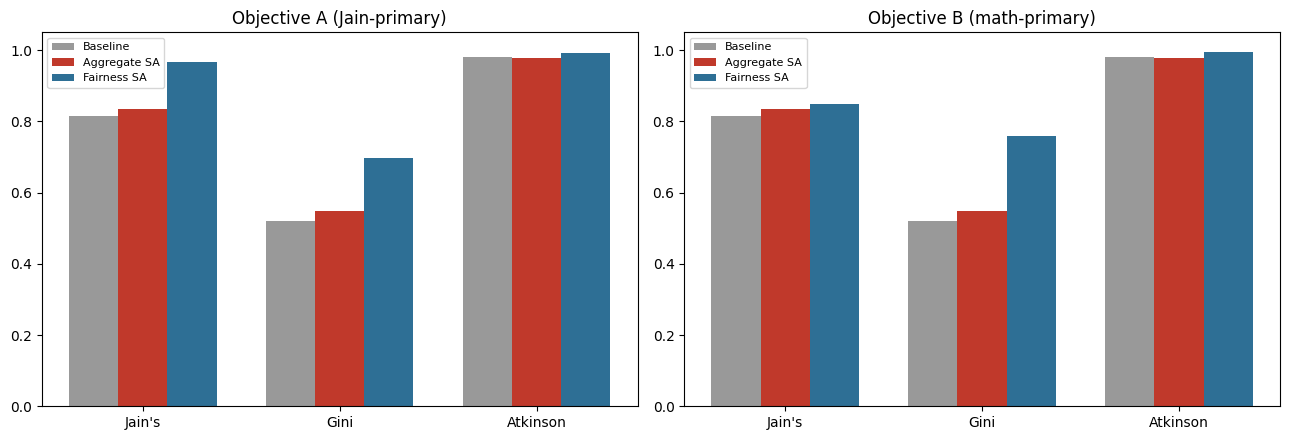

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
metrics = ["jain", "gini", "atkinson"]
labels = ["Jain's", "Gini", "Atkinson"]

for ax, (name, result) in zip(axes, [("Objective A (Jain-primary)", result_A),
                                       ("Objective B (math-primary)", result_B)]):
    baseline_vals = [result["baseline"][m] for m in metrics]
    agg_vals = [result["aggregate"][m] for m in metrics]
    fair_vals = [result["fairness"][m] for m in metrics]
    x = range(len(metrics))
    width = 0.25
    ax.bar([i - width for i in x], baseline_vals, width, label="Baseline", color="#999999")
    ax.bar(list(x), agg_vals, width, label="Aggregate SA", color="#C0392B")
    ax.bar([i + width for i in x], fair_vals, width, label="Fairness SA", color="#2E6F95")
    ax.set_xticks(list(x)); ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.05)
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("aggregate_vs_fairness_comparison.png", dpi=150)
plt.show()


## 9. Multi-seed robustness

Runs the fairness-active SA (Objective A, Jain-primary) across 10 different random
seeds, logs the final hard/logical/Jain/mean/SD for each, and reports the mean and SD
*across runs* — how much the outcome varies just from randomness, not from anything
about the objective itself. `ROBUSTNESS_ITERATIONS` (Section 0) is lower than
`MAIN_RUN_ITERATIONS` to keep 10 full runs practical in one sitting; raise it once
you're past checking this works and want the real numbers.

In [13]:
robustness_rows = []
for seed in range(ROBUSTNESS_SEED_COUNT):
    rng = random.Random(seed)
    best, best_cost, accepted, history = sa_optimise(
        sessions, cost_jain_primary, ROBUSTNESS_ITERATIONS, T0, COOLING, rng)
    r = cost_jain_primary(best)
    robustness_rows.append({
        "seed": seed, "hard": r["hard"], "logical": r["logical"],
        "jain": r["jain"], "gini": r["gini"], "atkinson": r["atkinson"],
        "mean_Vnorm": r["math"]["mean"], "sd_Vnorm": r["math"]["sd"], "max_Vnorm": r["math"]["max"],
        "accepted_moves": accepted,
    })

robustness_df = pd.DataFrame(robustness_rows)
print(robustness_df.to_string(index=False))
print()
summary = robustness_df[["hard", "logical", "jain", "gini", "atkinson", "mean_Vnorm", "sd_Vnorm"]].agg(["mean", "std"])
print("--- Across-seed summary (mean and std of each column, over 10 seeds) ---")
print(summary.to_string())
robustness_df.to_csv("seed_robustness_table.csv", index=False)


 seed  hard  logical     jain     gini  atkinson  mean_Vnorm  sd_Vnorm  max_Vnorm  accepted_moves
    0     2        1 0.846495 0.572231  0.982692    0.537083  0.410073   1.500050             878
    1     2        1 0.864541 0.555864  0.980430    0.560396  0.437931   1.666750             893
    2     3        0 0.908056 0.542658  0.979105    0.555278  0.459716   2.000000             879
    3     0        4 0.904953 0.546431  0.979020    0.571804  0.462854   2.000000             876
    4     3        3 0.884634 0.537510  0.978959    0.556510  0.461117   1.833400             918
    5     3        1 0.916637 0.541839  0.980368    0.534393  0.441982   2.000000             887
    6     3        3 0.884085 0.576493  0.982092    0.561255  0.420385   1.722233             897
    7     2        1 0.901965 0.571270  0.979784    0.604820  0.459966   2.000000             854
    8     3        2 0.917768 0.546353  0.980391    0.536325  0.438126   2.000000             872
    9     3        2

## 10. Final schedule and highest-burden tutors

Uses Objective A's fairness-SA result as "the" final schedule. Swap `result_A` for
`result_B` here if you want Objective B's result instead.

In [14]:
final_sessions = result_A["fairness_best"]

final_schedule_rows = []
for s in sorted(final_sessions, key=lambda s: (s["tutor"], DAY_ORDER.index(s["day"]), s["start"])):
    real_end = s["start"] + s["duration"]
    final_schedule_rows.append({
        "TUTOR_ID": s["tutor"], "COURSE_ID": s["course"], "CLASS_ID": s["class_id"],
        "SECTION": s["section"], "DAY": s["day"],
        "START": f"{s['start']//60:02d}:{s['start']%60:02d}",
        "END_ACTUAL": f"{real_end//60:02d}:{real_end%60:02d}",
        "END_SCHEDULED_BLOCK": f"{session_end(s)//60:02d}:{session_end(s)%60:02d}",
        "SLOTS_NEEDED": s["slots_needed"],
        "ROOM_ID": s["room"], "ROOM_TYPE": room_type_by_id.get(s["room"]), "CAMPUS_ID": s["campus"],
        "MERGED_GROUP_ID": s["merged_group"] or "",
    })

final_schedule_df = pd.DataFrame(final_schedule_rows)
final_schedule_df.to_csv(f"final_schedule_{SEMESTER}.csv", index=False)
print(f"Final schedule written to final_schedule_{SEMESTER}.csv ({len(final_schedule_df)} rows)")
final_schedule_df.head(15)


Final schedule written to final_schedule_25B.csv (556 rows)


,TUTOR_ID,COURSE_ID,CLASS_ID,SECTION,DAY,START,END_ACTUAL,END_SCHEDULED_BLOCK,SLOTS_NEEDED,ROOM_ID,ROOM_TYPE,CAMPUS_ID,MERGED_GROUP_ID
0,T001,IT7003,21263,013,Sunday,08:00,09:50,10:00,1,36.102 PDC,Lab,A,
1,T001,IT7003,21271,015,Sunday,12:00,13:50,14:00,1,36.102,Lab,A,
2,T001,IT7003,21269,014,Monday,10:00,11:50,12:00,1,19.104,General,A,MERGE157
3,T001,IT7003,21271,015,Monday,10:00,11:50,12:00,1,19.104,General,A,MERGE157
4,T001,IT7003,21271,015,Tuesday,08:00,09:50,10:00,1,20.121,Lab,B,
5,T001,IT7003,21263,013,Tuesday,10:00,11:50,12:00,1,25.113,Lab,B,
6,T001,IT7003,21269,014,Tuesday,14:00,15:50,16:00,1,20.209,Lab,B,
7,T001,IT7003,21269,014,Thursday,12:00,13:50,14:00,1,36A.109,Lab,A,
8,T002,IT7008,21205,001,Sunday,12:00,13:50,14:00,1,5.02,Lab,A,
9,T002,IT7008,21205,001,Tuesday,10:00,11:50,12:00,1,25.329,Lab,B,


In [15]:
final_V_norm = result_A["fairness"]["V_norm"]
baseline_V_norm = result_A["baseline"]["V_norm"]
highest_burden = sorted(final_V_norm, key=lambda t: final_V_norm[t], reverse=True)[:10]

tutor_classes_count = defaultdict(set)
for s in final_sessions:
    tutor_classes_count[s["tutor"]].add(s["class_id"])

print(f"{'TUTOR':8s} {'V_norm before':>14s} {'V_norm after':>14s} {'active profiles (weight)':>40s}")
for t in highest_burden:
    before = baseline_V_norm.get(t, 0.0)
    after = final_V_norm.get(t, 0.0)
    weights = tutor_weights.get(t, {})
    active = ", ".join(f"{p}={w:.2f}" for p, w in weights.items() if w > 0) or "none (P8)"
    print(f"{t:8s} {before:14.2f} {after:14.2f} {active:>40s}")


TUTOR     V_norm before   V_norm after                 active profiles (weight)
T110               0.94           2.11                P1=0.50, P3=0.17, P7=0.33
T002               1.33           1.33                         P3=0.67, P5=0.33
T090               0.94           1.06                P1=0.33, P3=0.50, P6=0.17
T056               1.33           1.00                         P3=0.67, P7=0.33
T017               1.25           1.00                                  P3=1.00
T043               0.89           0.83                P1=0.33, P3=0.17, P7=0.50
T011               1.11           0.78                         P2=0.33, P3=0.67
T076               0.83           0.71                P1=0.17, P3=0.33, P5=0.50
T077               0.96           0.67                P2=0.33, P3=0.50, P7=0.17
T089               1.00           0.67                                  P1=1.00


## 11. Notes for next steps

In [16]:
print("""
- MAIN_RUN_ITERATIONS and ROBUSTNESS_ITERATIONS (Section 0) are starting points sized
  to keep this notebook's total runtime practical, not tuned final values -- raise them
  once you have real results to build on.
- Two full objective versions exist side by side (Section 6-8); delete whichever your
  research doesn't end up using, each is self-contained.
- Room type, capacity, and merged-group handling all depend on Clean_Data_V3.ipynb's
  output -- rerun that first if you change any of its rules.
- Reusing this for another semester: change SEMESTER in Section 0 and rerun top to
  bottom, same as v2.
- Still open: which objective (A or B) is the "real" one for your thesis is your call,
  not resolved by this notebook -- both are built to the same standard so the choice is
  yours to make on the actual results, not on which was easier to build.
""")



- MAIN_RUN_ITERATIONS and ROBUSTNESS_ITERATIONS (Section 0) are starting points sized
  to keep this notebook's total runtime practical, not tuned final values -- raise them
  once you have real results to build on.
- Two full objective versions exist side by side (Section 6-8); delete whichever your
  research doesn't end up using, each is self-contained.
- Room type, capacity, and merged-group handling all depend on Clean_Data_V3.ipynb's
  output -- rerun that first if you change any of its rules.
- Reusing this for another semester: change SEMESTER in Section 0 and rerun top to
  bottom, same as v2.
- Still open: which objective (A or B) is the "real" one for your thesis is your call,
  not resolved by this notebook -- both are built to the same standard so the choice is
  yours to make on the actual results, not on which was easier to build.

